<a href="https://colab.research.google.com/github/manuelapop/health_classification_dataset_model_train/blob/main/healthdataclassificationfinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Python version: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Keras version: 3.10.0
sklearn version: 1.6.1
np version: 2.0.2
pd version: 2.2.2
(100000, 48)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   survey_code               100000 non-null  int64  
 1   age                       100000 non-null  int64  
 2   gender                    100000 non-null  object 
 3   height                    100000 non-null  float64
 4   weight                    100000 non-null  float64
 5   bmi                       100000 non-null  float64
 6   bmi_estimated             100000 non-null  float64
 7   bmi_scaled                100000 non-null  float64
 8   bmi_corrected             100000 non-null  float64
 9   waist_size                100000 non-null  float64
 10  blood_pressure            92331 non-null   float64
 

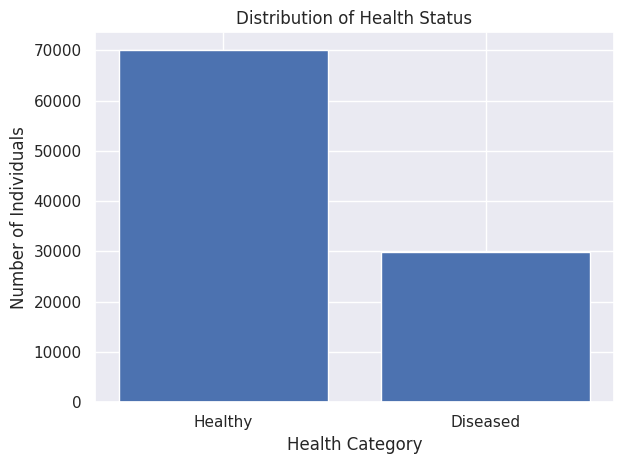

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 8)              │           616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 777 (3.04 KB)

 Trainable params: 777 (3.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.6551 - loss: 0.6369 - val_accuracy: 0.7000 - val_loss: 0.6113
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7017 - loss: 0.6101 - val_accuracy: 0.7000 - val_loss: 0.6109
Epoch 3/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7024 - loss: 0.6090 - val_accuracy: 0.7000 - val_loss: 0.6109
Epoch 4/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7007 - loss: 0.6104 - val_accuracy: 0.7000 - val_loss: 0.6107
Epoch 5/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7016 - loss: 0.6094 - val_accuracy: 0.7000 - val_loss: 0.6107
Epoch 6/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7014 - loss: 0.6095 - val_accuracy: 0.7000 - val_loss: 0.6108
Epoch 7/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7014 - loss: 0.6093 - val_accuracy: 0.7000 - val_loss: 0.6108
Epoch 8/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7000 - loss: 0.6104 - val_accuracy: 0

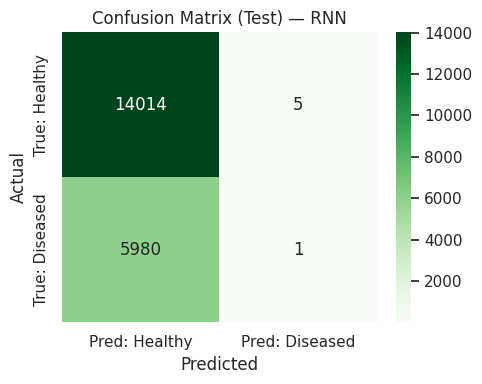

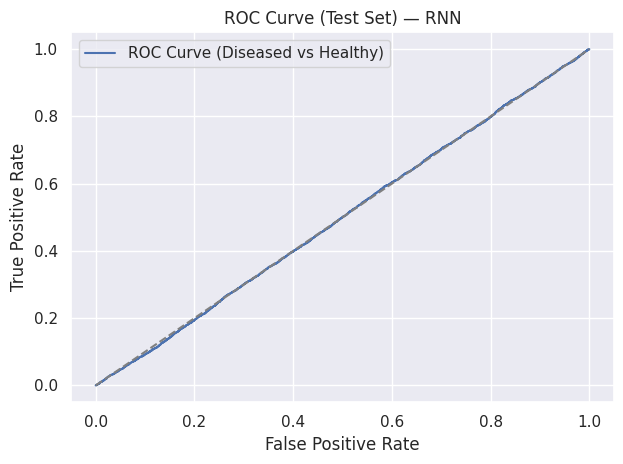

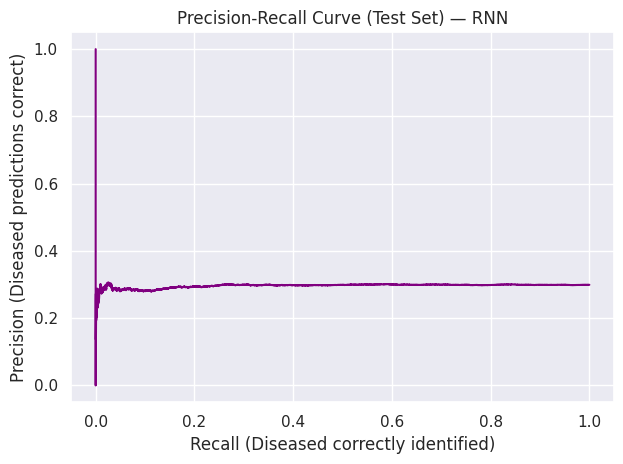

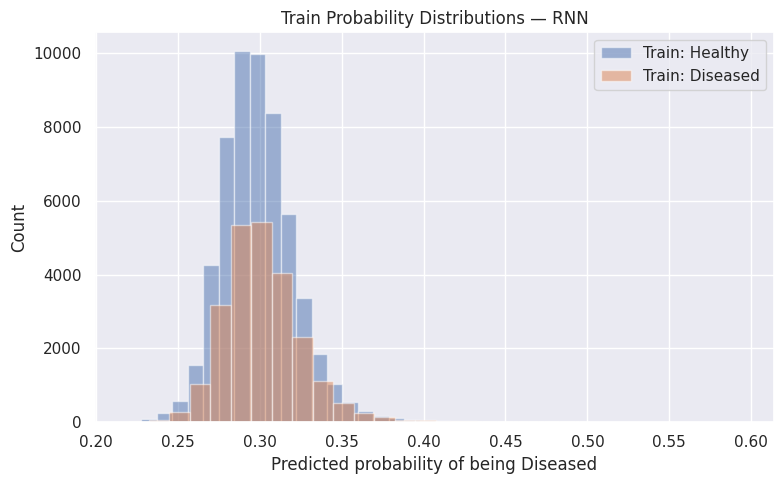

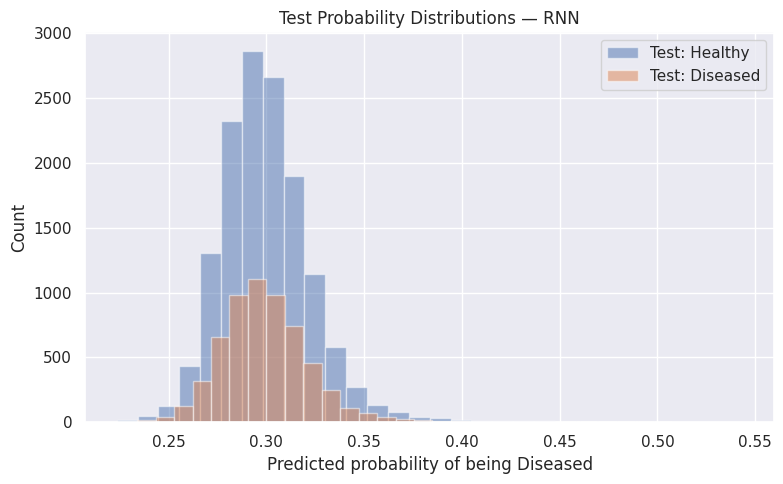


Best test accuracy (RNN): 0.701 at threshold=0.550 (F1=0.000)

[HGB] ROC-AUC: 0.500
[HGB] Classification Report @thr=0.50
              precision    recall  f1-score   support

     Healthy      0.701     1.000     0.824     14019
    Diseased      0.000     0.000     0.000      5981

    accuracy                          0.701     20000
   macro avg      0.350     0.500     0.412     20000
weighted avg      0.491     0.701     0.578     20000

[HGB] Confusion matrix @thr=0.50:
 [[14019     0]
 [ 5981     0]]


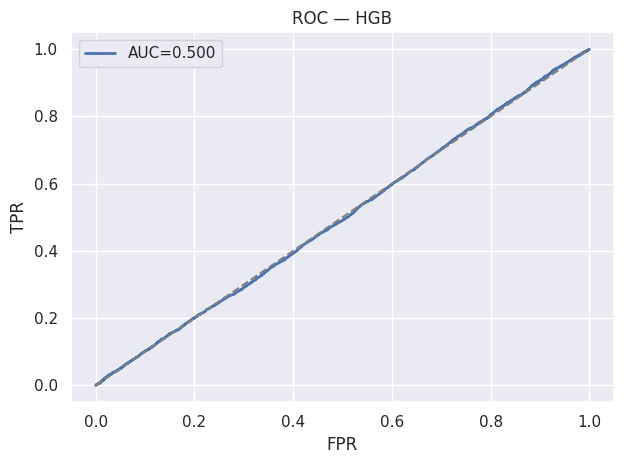

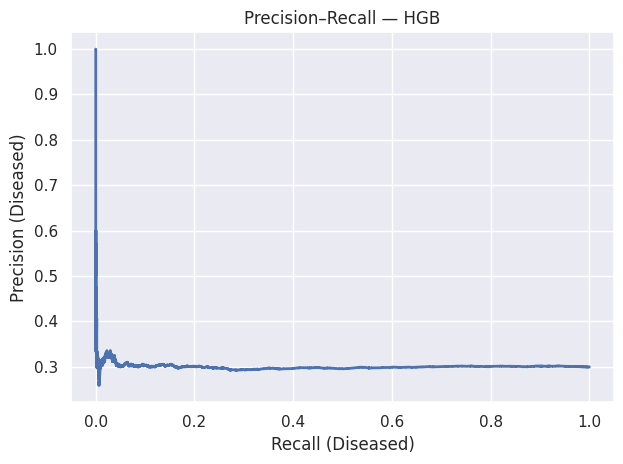

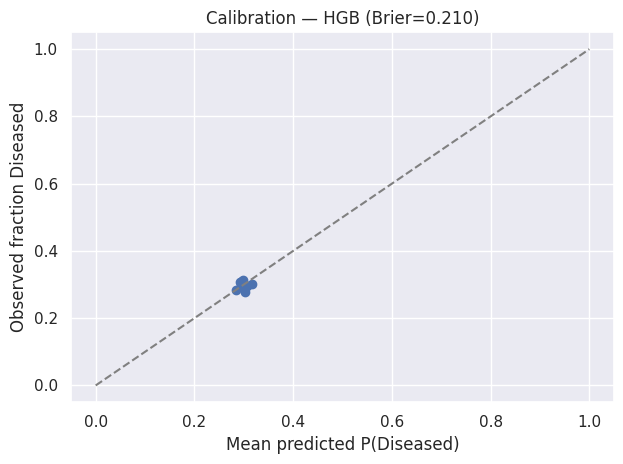

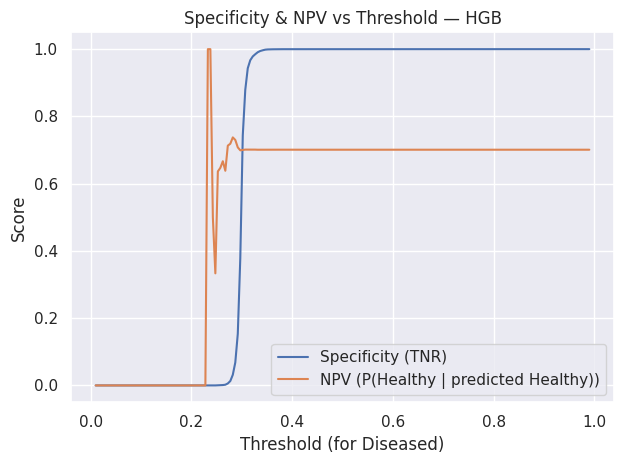

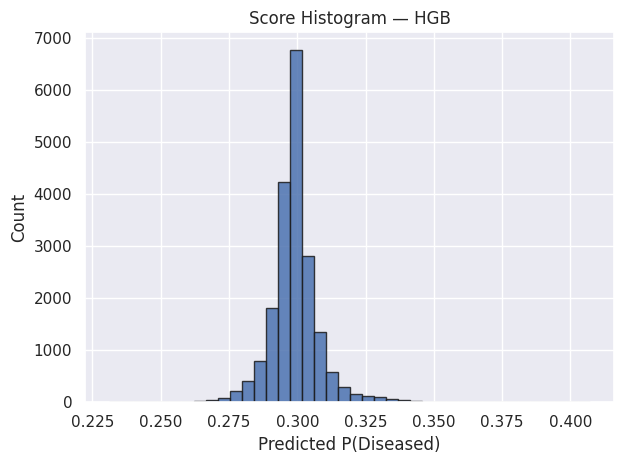

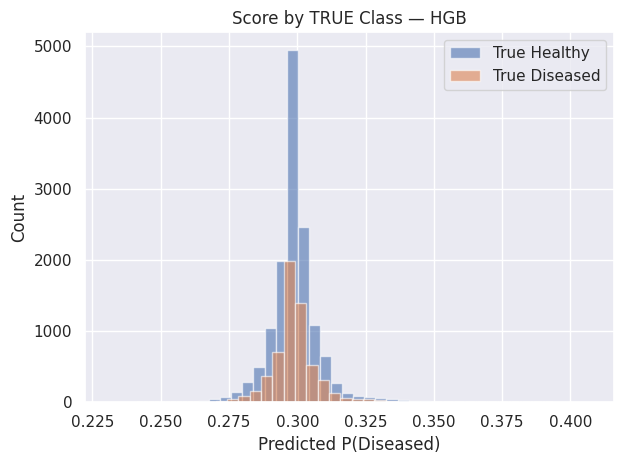


[HGB] Confusion Matrix @thr=0.15:
[[    0 14019]
 [    0  5981]]


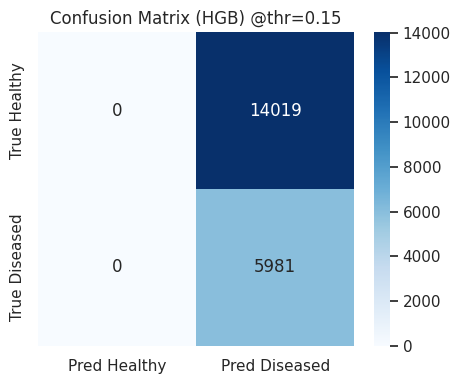


[HGB] Confusion Matrix @thr=0.50:
[[14019     0]
 [ 5981     0]]


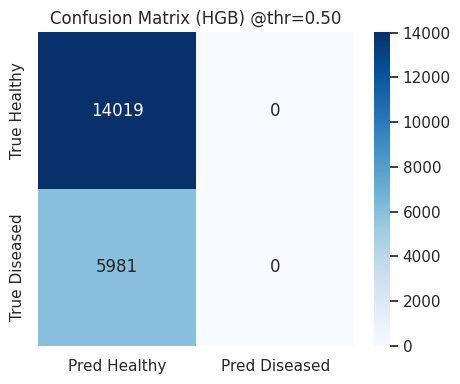

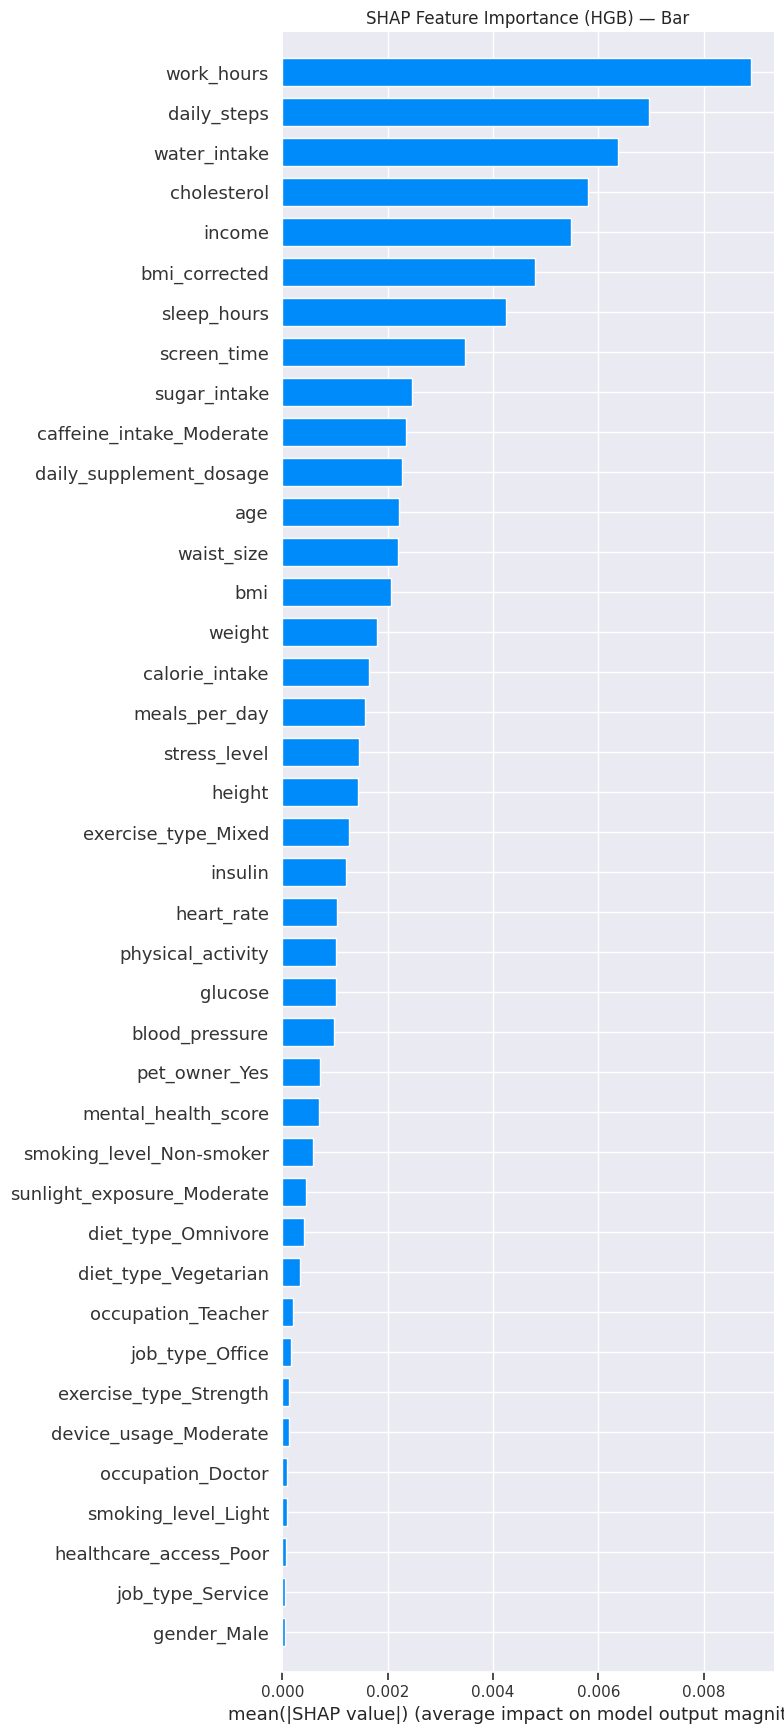

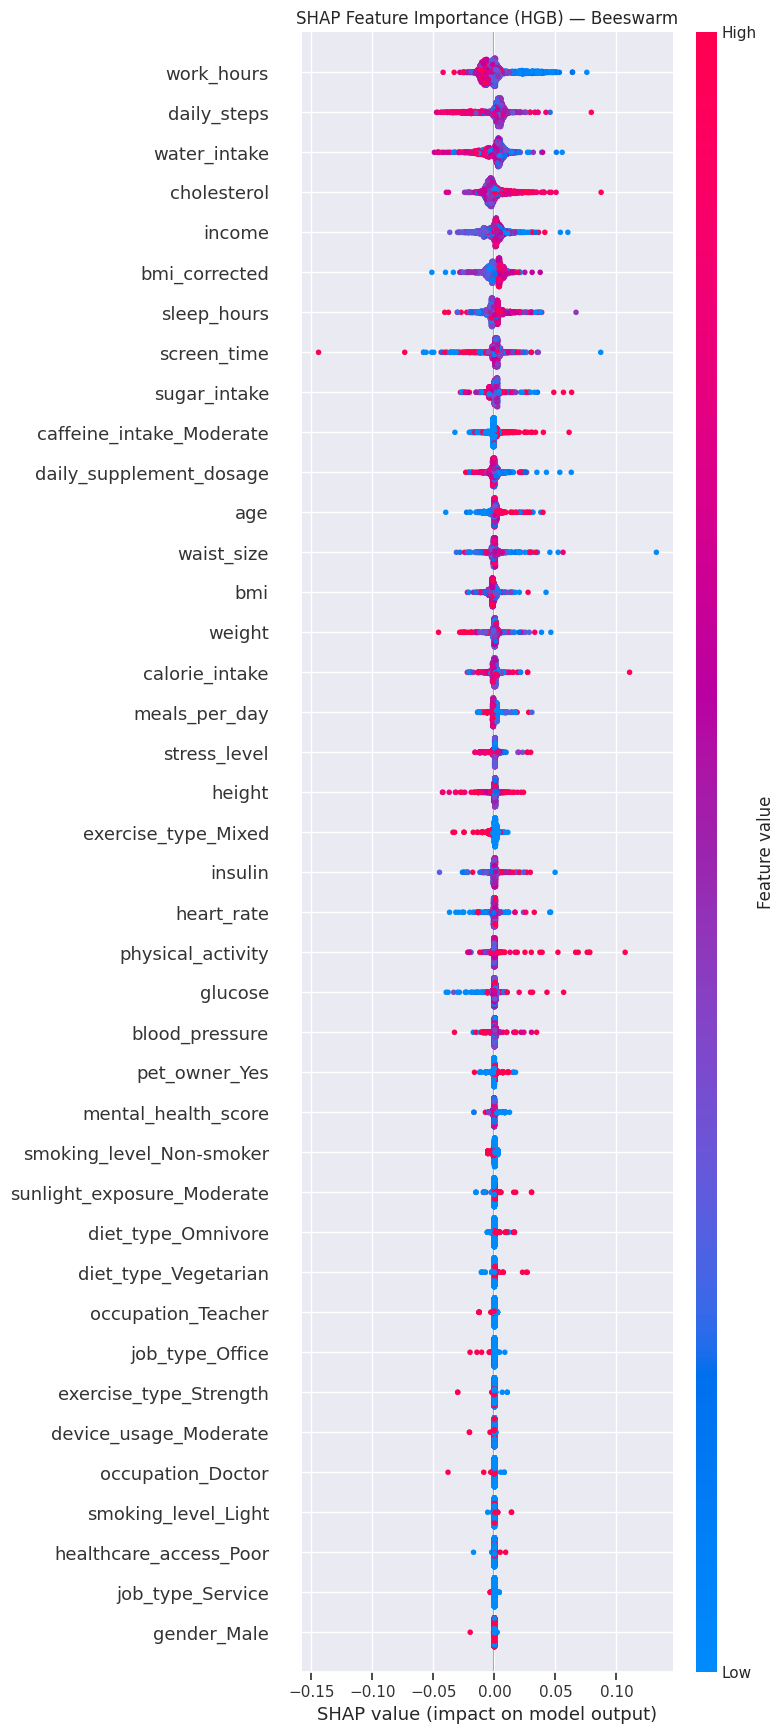

In [3]:
# ============================================================
# Your original imports (kept) + minor extras for saving plots
# ============================================================
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense, Input, Dropout, BatchNormalization
from keras.optimizers import Adam
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, roc_auc_score

from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report, mean_squared_error
)

import seaborn as sns
plt.style.use("ggplot")
sns.set_theme()

import sys
import keras
import sklearn
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

def save_and_show(fname):
    plt.tight_layout()
    plt.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

print(f'Python version: {sys.version}')
print(f'Keras version: {keras.__version__}')
print(f'sklearn version: {sklearn.__version__}')
print(f'np version: {np.__version__}')
print(f'pd version: {pd.__version__}')

# ============================================================
# Load data (your path)
# ============================================================
data_path = './health_lifestyle_classification.csv' # change this if necessary
df = pd.read_csv(data_path)

print(df.shape)
df.head()
df.info()

# Class distribution plot
counts = (
    df['target'].astype(str).str.lower().value_counts()
          .reindex(['healthy','diseased'])   # enforce order
)
plt.figure()
plt.bar(counts.index.str.title(), counts.values)
plt.title('Distribution of Health Status')
plt.ylabel('Number of Individuals')
plt.xlabel('Health Category')
save_and_show("healh_status_distribution.png")

# Drop non-informative ID column (kept)
if 'survey_code' in df.columns:
    df = df.drop(columns=['survey_code'])

# Make sure labels are numeric (robust lower)
y = df['target'].astype(str).str.lower().map({'healthy': 0, 'diseased': 1}).astype('int32')

# Rebuild X from scratch
X = df.drop(columns=['target'])

# ============================================================
# Split first so we fit scalers on train only
# ============================================================
X_train_df, X_test_df, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Keep integer copies for classical classifiers (HGB)
y_train_int = y_train.copy().astype(int)
y_test_int  = y_test.copy().astype(int)

# ============================================================
# Your RNN path (unchanged)
# ============================================================
# Numeric/categorical split
num_cols = X_train_df.select_dtypes(include=['float64','int64','int32','float32']).columns
cat_cols = X_train_df.select_dtypes(include=['object']).columns

# Impute
X_train_df[num_cols] = X_train_df[num_cols].fillna(X_train_df[num_cols].median())
X_test_df[num_cols]  = X_test_df[num_cols].fillna(X_train_df[num_cols].median())

X_train_df[cat_cols] = X_train_df[cat_cols].fillna('Unknown')
X_test_df[cat_cols]  = X_test_df[cat_cols].fillna('Unknown')

# One-hot encode categoricals
X_train_df = pd.get_dummies(X_train_df, columns=cat_cols, drop_first=True)
X_test_df  = pd.get_dummies(X_test_df,  columns=cat_cols, drop_first=True)

# Align columns
X_train_df, X_test_df = X_train_df.align(X_test_df, join='left', axis=1, fill_value=0)

# Scale numeric-like data
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_df.values)
X_test  = scaler.transform(X_test_df.values)

# Convert to proper numpy dtypes and RNN shape
X_train = np.asarray(X_train, dtype='float32')[:, None, :]  # (samples, 1, features)
X_test  = np.asarray(X_test,  dtype='float32')[:, None, :]
y_train_np = np.asarray(y_train, dtype='float32')           # (samples,)
y_test_np  = np.asarray(y_test,  dtype='float32')

# RNN model (your original)
model = Sequential([
    Input(shape=(1, X_train.shape[2])),
    SimpleRNN(8, activation='tanh'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

optimizer = Adam(learning_rate=0.001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

history = model.fit(
    X_train, y_train_np,
    epochs=20, batch_size=256,
    validation_split=0.2,
    verbose=1
)

loss, acc = model.evaluate(X_test, y_test_np, verbose=0)
print(f"Test Accuracy: {acc:.3f}")

# 1) Predict probabilities (sigmoid outputs in [0,1])
train_proba = model.predict(X_train).ravel()
test_proba  = model.predict(X_test).ravel()

# 2) Convert to class labels with a threshold (default 0.5)
thr = 0.5
train_pred = (train_proba >= thr).astype(int)
test_pred  = (test_proba  >= thr).astype(int)

# 3) Metrics
print("== Train ==")
print("Accuracy :", accuracy_score(y_train_np, train_pred))
print("F1 Score :", f1_score(y_train_np, train_pred))
print("Precision:", precision_score(y_train_np, train_pred))
print("Recall   :", recall_score(y_train_np, train_pred))
print("AUC      :", roc_auc_score(y_train_np, train_proba))

print("\n== Test ==")
print("Accuracy :", accuracy_score(y_test_np, test_pred))
print("F1 Score :", f1_score(y_test_np, test_pred))
print("Precision:", precision_score(y_test_np, test_pred))
print("Recall   :", recall_score(y_test_np, test_pred))
print("AUC      :", roc_auc_score(y_test_np, test_proba))

print("\nClassification Report (Test):")
target_names = ['Healthy', 'Diseased']
print(classification_report(y_test_np, test_pred, target_names=target_names, digits=3))

# 4) Confusion matrix (test)
cm = confusion_matrix(y_test_np, test_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Pred: Healthy', 'Pred: Diseased'],
            yticklabels=['True: Healthy', 'True: Diseased'])
plt.title("Confusion Matrix (Test) — RNN")
plt.ylabel("Actual"); plt.xlabel("Predicted")
save_and_show("Confusion_Matrix_RNN.png")

# 5) ROC curve (test)
fpr, tpr, _ = roc_curve(y_test_np, test_proba)
plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (Diseased vs Healthy)")
plt.plot([0, 1], [0, 1], linestyle="--", color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Test Set) — RNN")
plt.legend()
save_and_show("ROC_RNN.png")

# 6) Precision-Recall curve (test)
prec, rec, _ = precision_recall_curve(y_test_np, test_proba)
plt.figure()
plt.plot(rec, prec, color='purple')
plt.xlabel("Recall (Diseased correctly identified)")
plt.ylabel("Precision (Diseased predictions correct)")
plt.title("Precision-Recall Curve (Test Set) — RNN")
save_and_show("PR_RNN.png")

# 7) Probability histograms (confidence visualization)
plt.figure(figsize=(8,5))
plt.hist(train_proba[y_train_np == 0], bins=30, alpha=0.5, label="Train: Healthy")
plt.hist(train_proba[y_train_np == 1], bins=30, alpha=0.5, label="Train: Diseased")
plt.xlabel("Predicted probability of being Diseased")
plt.ylabel("Count")
plt.title("Train Probability Distributions — RNN")
plt.legend()
save_and_show("predicted_probability_train_RNN.png")

plt.figure(figsize=(8,5))
plt.hist(test_proba[y_test_np == 0], bins=30, alpha=0.5, label="Test: Healthy")
plt.hist(test_proba[y_test_np == 1], bins=30, alpha=0.5, label="Test: Diseased")
plt.xlabel("Predicted probability of being Diseased")
plt.ylabel("Count")
plt.title("Test Probability Distributions — RNN")
plt.legend()
save_and_show("predicted_probability_test_RNN.png")

# 8) Optional: best threshold for accuracy (RNN)
best = (0, 0, 0)
for thr_try in np.linspace(0.2, 0.8, 25):
    pred_try = (test_proba >= thr_try).astype(int)
    acc_try = accuracy_score(y_test_np, pred_try)
    f1_try  = f1_score(y_test_np, pred_try)
    if acc_try > best[0]:
        best = (acc_try, thr_try, f1_try)
print(f"\nBest test accuracy (RNN): {best[0]:.3f} at threshold={best[1]:.3f} (F1={best[2]:.3f})")

# ============================================================
# NEW: HGB baseline + SHAP (integrated & all plots saved)
# ============================================================

# Train HGB on the OHE dataframes (no scaling required, but we used scaled arrays above for RNN)
hgb = HistGradientBoostingClassifier(
    learning_rate=0.08,
    max_iter=500,
    early_stopping=True,
    random_state=SEED
)
hgb.fit(X_train_df.values, y_train_int.values)

proba_hgb = hgb.predict_proba(X_test_df.values)[:, 1]
pred_hgb05 = (proba_hgb >= 0.5).astype(int)

print(f"\n[HGB] ROC-AUC: {roc_auc_score(y_test_int, proba_hgb):.3f}")
print("[HGB] Classification Report @thr=0.50")
print(classification_report(y_test_int, pred_hgb05, target_names=['Healthy','Diseased'], digits=3))
print("[HGB] Confusion matrix @thr=0.50:\n", confusion_matrix(y_test_int, pred_hgb05))

# --- ROC (HGB)
fpr_hgb, tpr_hgb, _ = roc_curve(y_test_int, proba_hgb)
plt.figure()
plt.plot(fpr_hgb, tpr_hgb, lw=2, label=f"AUC={roc_auc_score(y_test_int, proba_hgb):.3f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC — HGB"); plt.legend()
save_and_show("ROC_HGB.png")

# --- PR (HGB)
prec_hgb, rec_hgb, _ = precision_recall_curve(y_test_int, proba_hgb)
plt.figure()
plt.plot(rec_hgb, prec_hgb, lw=2)
plt.xlabel("Recall (Diseased)"); plt.ylabel("Precision (Diseased)"); plt.title("Precision–Recall — HGB")
save_and_show("PR_HGB.png")

# --- Calibration (HGB)
from sklearn.calibration import calibration_curve, CalibrationDisplay
prob_true_hgb, prob_pred_hgb = calibration_curve(y_test_int, proba_hgb, n_bins=10, strategy="quantile")
brier_hgb = sklearn.metrics.brier_score_loss(y_test_int, proba_hgb)
plt.figure()
plt.plot(prob_pred_hgb, prob_true_hgb, marker='o'); plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("Mean predicted P(Diseased)"); plt.ylabel("Observed fraction Diseased")
plt.title(f"Calibration — HGB (Brier={brier_hgb:.3f})")
save_and_show("Calibration_HGB.png")

# --- Specificity & NPV vs threshold (HGB)
thr_grid = np.linspace(0.01, 0.99, 199)
specs, npvs = [], []
for t in thr_grid:
    pred = (proba_hgb >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_int, pred).ravel()
    specificity = tn / (tn + fp + 1e-9)
    npv = tn / (tn + fn + 1e-9)
    specs.append(specificity); npvs.append(npv)
plt.figure()
plt.plot(thr_grid, specs, label="Specificity (TNR)")
plt.plot(thr_grid, npvs,  label="NPV (P(Healthy | predicted Healthy))")
plt.xlabel("Threshold (for Diseased)"); plt.ylabel("Score"); plt.legend()
plt.title("Specificity & NPV vs Threshold — HGB")
save_and_show("Spec_NPV_vs_Threshold_HGB.png")

# --- Score histograms (HGB)
plt.figure()
plt.hist(proba_hgb, bins=40, alpha=0.85, edgecolor='k')
plt.xlabel("Predicted P(Diseased)"); plt.ylabel("Count"); plt.title("Score Histogram — HGB")
save_and_show("Score_Hist_HGB.png")

plt.figure()
plt.hist(proba_hgb[(y_test_int==0)], bins=40, alpha=0.6, label="True Healthy")
plt.hist(proba_hgb[(y_test_int==1)], bins=40, alpha=0.6, label="True Diseased")
plt.xlabel("Predicted P(Diseased)"); plt.ylabel("Count"); plt.legend()
plt.title("Score by TRUE Class — HGB")
save_and_show("Score_ByTrueClass_HGB.png")

# --- Confusion matrices saved at a couple thresholds (HGB)
def cm_saved(y_true, proba, thr, tag):
    pred = (proba >= thr).astype(int)
    cm = confusion_matrix(y_true, pred)
    print(f"\n[{tag}] Confusion Matrix @thr={thr:.2f}:\n{cm}")
    plt.figure(figsize=(4.8,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Pred Healthy', 'Pred Diseased'],
                yticklabels=['True Healthy', 'True Diseased'])
    plt.title(f"Confusion Matrix ({tag}) @thr={thr:.2f}")
    save_and_show(f"CM_{tag}_thr{thr:.2f}.png")

for thr in [0.15, 0.50]:
    cm_saved(y_test_int, proba_hgb, thr, tag="HGB")

# ============================================================
# SHAP integration (as you requested) + fallbacks, SAVED
# Using HGB trained on X_train_df/X_test_df
# ============================================================
try:
    import shap
    _ = shap.__version__
    # TreeExplainer for HGB (interventional helps with correlated features)
    explainer = shap.TreeExplainer(hgb, feature_perturbation="interventional")

    # Background/sample sizes to keep it fast
    n_show = min(2000, len(X_test_df))
    show_idx = np.arange(n_show)

    shap_vals = explainer.shap_values(X_test_df.values[show_idx])

    # Bar plot
    shap.summary_plot(shap_vals, X_test_df.iloc[show_idx], plot_type="bar", max_display=40, show=False)
    plt.title("SHAP Feature Importance (HGB) — Bar")
    save_and_show("SHAP_bar_HGB.png")

    # Beeswarm/dot
    shap.summary_plot(shap_vals, X_test_df.iloc[show_idx], plot_type="dot", max_display=40, show=False)
    plt.title("SHAP Feature Importance (HGB) — Beeswarm")
    save_and_show("SHAP_beeswarm_HGB.png")

except Exception as e:
    print("\n[SHAP] Skipping SHAP plots. Reason:", str(e))
    # Fallback 1: permutation importance (saves figure)
    try:
        from sklearn.inspection import permutation_importance
        r = permutation_importance(
            hgb, X_test_df.values, y_test_int.values,
            scoring="roc_auc", n_repeats=5, random_state=SEED, n_jobs=-1
        )
        imp = pd.Series(r.importances_mean, index=X_test_df.columns).sort_values(ascending=False)
        print("\nTop 40 permutation importances (mean ΔAUC):")
        print(imp.head(40))

        plt.figure(figsize=(7,6))
        topi = imp.head(40).sort_values()
        plt.barh(topi.index, topi.values)
        plt.xlabel("Mean ΔAUC on permutation"); plt.title("Permutation Importance (HGB)")
        save_and_show("PermutationImportance_HGB.png")

    except Exception as ee:
        # Fallback 2: correlation proxy with model scores (as you asked)
        print("[Permutation] Failed too. Reason:", str(ee))
        try:
            scores_corr = pd.Series(np.corrcoef(X_test_df.values.T, proba_hgb)[-1, :-1], index=X_test_df.columns)
            top40 = scores_corr.abs().sort_values(ascending=False).head(40)
            print("\nTop 40 proxy 'importance' via |corr(feature, P(Diseased))|:")
            print(top40)

            plt.figure(figsize=(7,6))
            plt.barh(top40.index[::-1], top40.values[::-1])
            plt.title("Proxy Importance via |corr(feature, score)| (HGB)")
            plt.xlabel("|corr| with P(Diseased)")
            save_and_show("ProxyCorrImportance_HGB.png")
        except Exception as eee:
            print("[Proxy] Importance proxy failed as well:", str(eee))
